# Lab 12: Regression I

Nonparametric regression using Nadaraya-Watson kernel estimator and smoothing splines.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

np.random.seed(42)

## Task 1: Generate artificial data

Generate data from the model:
$$y = g(x) + \varepsilon, \quad g(x) = 4.26(e^{-x} - 4e^{-2x} + 3e^{-3x}), \quad \varepsilon \sim \mathcal{N}(0, 0.1^2)$$

with $x_i \sim \text{Uniform}(0, 4)$. Generate both a training set and an independent test set.

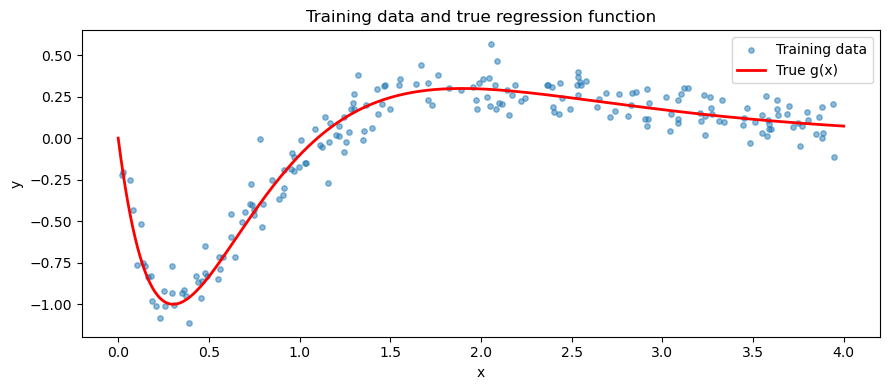

In [2]:
def g(x):
    """True regression function."""
    return 4.26 * (np.exp(-x) - 4*np.exp(-2*x) + 3*np.exp(-3*x))

def generate_data(n, seed=None):
    """Generate n observations from the model y = g(x) + eps."""
    if seed is not None:
        np.random.seed(seed)
    X = np.random.uniform(0, 4, n)
    eps = np.random.normal(0, 0.1, n)  # eps ~ N(0, 0.1^2)
    y = g(X) + eps
    return X, y

# training and test sets
X_train, y_train = generate_data(n=200, seed=42)
X_test,  y_test  = generate_data(n=100, seed=99)

x_grid = np.linspace(0, 4, 300)  # fine grid for plotting curves

plt.figure(figsize=(9, 4))
plt.scatter(X_train, y_train, s=15, alpha=0.5, label='Training data')
plt.plot(x_grid, g(x_grid), 'r-', lw=2, label='True g(x)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Training data and true regression function')
plt.legend()
plt.tight_layout()
plt.show()

## Task 2: Nadaraya-Watson kernel regression estimator

$$\hat{g}_h(x) = \frac{\sum_{i=1}^n K\!\left(\frac{x - x_i}{h}\right) y_i}{\sum_{i=1}^n K\!\left(\frac{x - x_i}{h}\right)}$$

Implemented with **Gaussian** and **Epanechnikov** kernels.

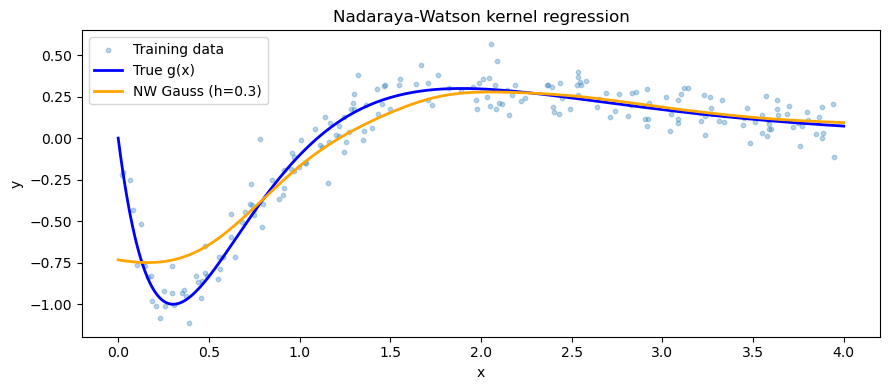

In [3]:
# ── kernels ───────────────────────────────────────────────────────────────────

def gaussian_kernel(x, x_i, h):
    u = (x - x_i) / h
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def epanechnikov_kernel(x, x_i, h):
    u = (x - x_i) / h
    return np.where(np.abs(u) <= 1, 0.75 * (1 - u**2), 0.0)


# ── Nadaraya-Watson estimator at a single point x ────────────────────────────

def nadaraya_watson(kernel_function, X, y, h, x):
    """Compute NW estimate at scalar x."""
    weights = kernel_function(x, X, h)   # vectorised over training points
    denom = weights.sum()
    if denom < 1e-10:                    # guard against empty neighbourhood
        return np.nan
    return (weights @ y) / denom


# ── predict over an array of points ──────────────────────────────────────────

def nw_predict(kernel_function, X_train, y_train, h, X_new):
    """NW predictions for every point in X_new."""
    return np.array([
        nadaraya_watson(kernel_function, X_train, y_train, h, x)
        for x in X_new
    ])


# ── quick sanity check ────────────────────────────────────────────────────────
h = 0.3
y_hat = nw_predict(gaussian_kernel, X_train, y_train, h, x_grid)

plt.figure(figsize=(9, 4))
plt.scatter(X_train, y_train, s=10, alpha=0.3, label='Training data')
plt.plot(x_grid, g(x_grid), 'b-', lw=2, label='True g(x)')
plt.plot(x_grid, y_hat, 'orange', lw=2, label=f'NW Gauss (h={h})')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Nadaraya-Watson kernel regression')
plt.legend()
plt.tight_layout()
plt.show()

## Task 3: Compare Nadaraya-Watson vs Smoothing Splines

MSE Nadaraya-Watson (Gauss, h=0.3): 0.02367
MSE Smoothing Spline (s=0.5):       0.01671


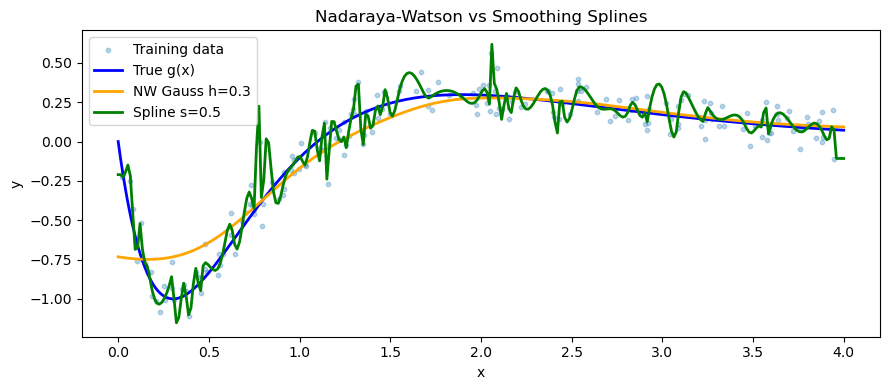

In [9]:
h_nw = 0.3
s_sp = 0.5   # smoothing parameter for UnivariateSpline

# Nadaraya-Watson (Gaussian)
y_pred_nw = nw_predict(gaussian_kernel, X_train, y_train, h_nw, X_test)
mse_nw = np.mean((y_pred_nw - y_test)**2)

# Smoothing spline — UnivariateSpline requires sorted X
idx = np.argsort(X_train)
spline = UnivariateSpline(X_train[idx], y_train[idx], s=s_sp, ext='const')
y_pred_sp = spline(X_test)
mse_sp = np.mean((y_pred_sp - y_test)**2)

print(f"MSE Nadaraya-Watson (Gauss, h={h_nw}): {mse_nw:.5f}")
print(f"MSE Smoothing Spline (s={s_sp}):       {mse_sp:.5f}")

# plot on x_grid
y_grid_nw = nw_predict(gaussian_kernel, X_train, y_train, h_nw, x_grid)
y_grid_sp = spline(x_grid)

plt.figure(figsize=(9, 4))
plt.scatter(X_train, y_train, s=10, alpha=0.3, label='Training data')
plt.plot(x_grid, g(x_grid), 'b-', lw=2, label='True g(x)')
plt.plot(x_grid, y_grid_nw, 'orange', lw=2, label=f'NW Gauss h={h_nw}')
plt.plot(x_grid, y_grid_sp, 'green',  lw=2, label=f'Spline s={s_sp}')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Nadaraya-Watson vs Smoothing Splines')
plt.legend()
plt.tight_layout()
plt.show()

## Task 4: Effect of the smoothing parameter — bias-variance tradeoff

Compare several values of `h` (NW) and `s` (splines). Explain what happens when the curve is too rough or too smooth.

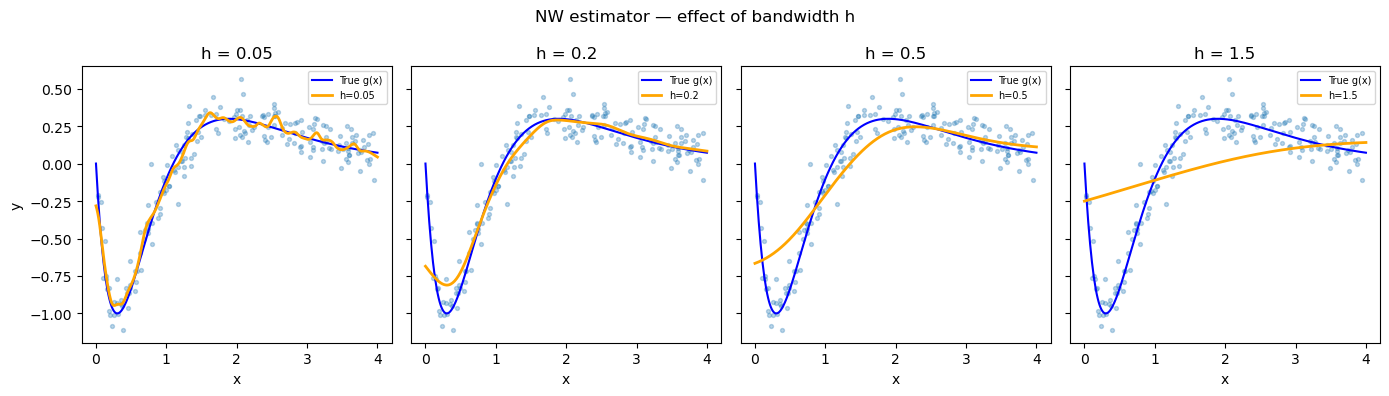

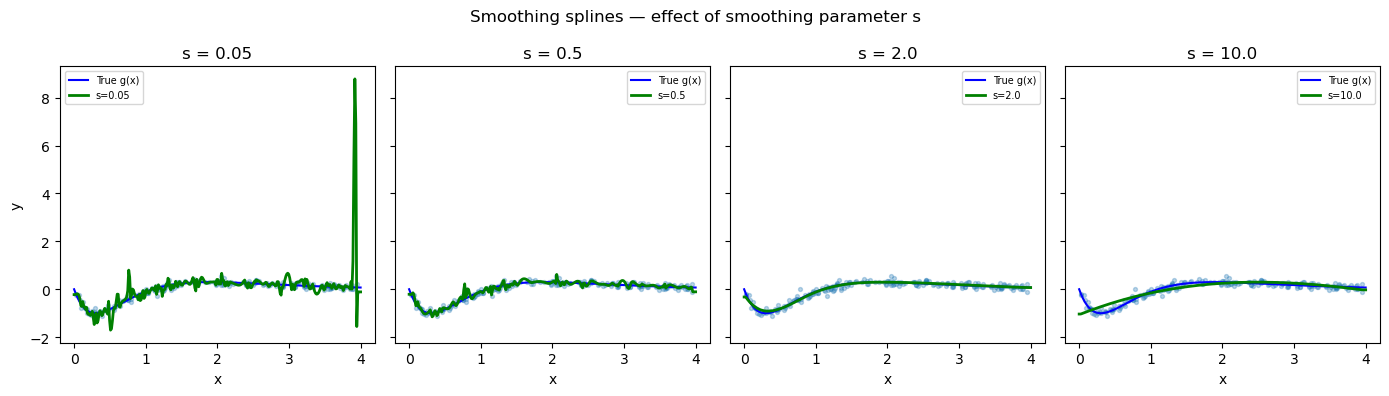

In [5]:
# ── Nadaraya-Watson: vary h ───────────────────────────────────────────────────
h_values = [0.05, 0.2, 0.5, 1.5]

fig, axes = plt.subplots(1, len(h_values), figsize=(14, 4), sharey=True)
for ax, h in zip(axes, h_values):
    y_hat = nw_predict(gaussian_kernel, X_train, y_train, h, x_grid)
    ax.scatter(X_train, y_train, s=8, alpha=0.3)
    ax.plot(x_grid, g(x_grid), 'b-', lw=1.5, label='True g(x)')
    ax.plot(x_grid, y_hat, 'orange', lw=2, label=f'h={h}')
    ax.set_title(f'h = {h}')
    ax.set_xlabel('x')
    ax.legend(fontsize=7)
axes[0].set_ylabel('y')
fig.suptitle('NW estimator — effect of bandwidth h', fontsize=12)
plt.tight_layout()
plt.show()

# ── Smoothing splines: vary s ─────────────────────────────────────────────────
s_values = [0.05, 0.5, 2.0, 10.0]

fig, axes = plt.subplots(1, len(s_values), figsize=(14, 4), sharey=True)
for ax, s in zip(axes, s_values):
    sp = UnivariateSpline(X_train[idx], y_train[idx], s=s, ext='const')
    ax.scatter(X_train, y_train, s=8, alpha=0.3)
    ax.plot(x_grid, g(x_grid), 'b-', lw=1.5, label='True g(x)')
    ax.plot(x_grid, sp(x_grid), 'green', lw=2, label=f's={s}')
    ax.set_title(f's = {s}')
    ax.set_xlabel('x')
    ax.legend(fontsize=7)
axes[0].set_ylabel('y')
fig.suptitle('Smoothing splines — effect of smoothing parameter s', fontsize=12)
plt.tight_layout()
plt.show()

**Observations:**

- **Too rough** (small `h` / small `s`): the curve fits training noise — high variance, low bias. Overfitting.
- **Too smooth** (large `h` / large `s`): the curve misses the true shape — low variance, high bias. Underfitting.
- This is the **bias-variance tradeoff**: reducing one increases the other. The optimal parameter minimises total test error.

## Task 5: Visualise results — training data, true g(x), fitted curves

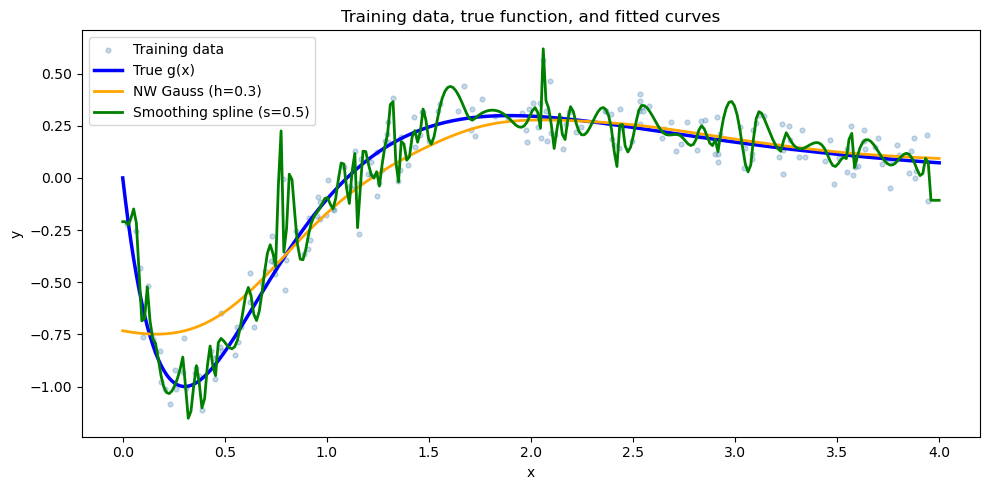

In [11]:
h_best  = 0.3
s_best  = 0.5

y_nw_gauss = nw_predict(gaussian_kernel, X_train, y_train, h_best, x_grid)
y_nw_epan = nw_predict(epanechnikov_kernel, X_train, y_train, h_best, x_grid)
sp_best = UnivariateSpline(X_train[idx], y_train[idx], s=s_best, ext='const')

plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, s=12, alpha=0.3, color='steelblue', label='Training data')
plt.plot(x_grid, g(x_grid),       'b-',     lw=2.5, label='True g(x)')
plt.plot(x_grid, y_nw_gauss,      'orange',  lw=2,   label=f'NW Gauss (h={h_best})')
plt.plot(x_grid, sp_best(x_grid), 'green',   lw=2,   label=f'Smoothing spline (s={s_best})')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Training data, true function, and fitted curves')
plt.legend()
plt.tight_layout()
plt.show()

## Task 6: MSE\_g (function estimation error) vs MSE\_y (prediction error)

$$\text{MSE}_g = \frac{1}{n}\sum_{i=1}^n [g(x_i) - \hat{g}(x_i)]^2 \qquad \text{MSE}_y = \frac{1}{n}\sum_{i=1}^n [y_i - \hat{g}(x_i)]^2$$

Compute both on the training set and the test set.

In [12]:
def compute_errors(y_pred, y_true, X_points):
    """Return MSE_g and MSE_y for a given set of predictions."""
    mse_g = np.mean((g(X_points) - y_pred)**2)   # vs true function
    mse_y = np.mean((y_true      - y_pred)**2)   # vs noisy observations
    return mse_g, mse_y

# predictions on train and test
y_nw_train = nw_predict(gaussian_kernel, X_train, y_train, h_best, X_train)
y_nw_test  = nw_predict(gaussian_kernel, X_train, y_train, h_best, X_test)
y_sp_train = sp_best(X_train)
y_sp_test  = sp_best(X_test)

print("=== Nadaraya-Watson (Gauss) ===")
msg, msy = compute_errors(y_nw_train, y_train, X_train)
print(f"  Train  — MSE_g: {msg:.5f}  |  MSE_y: {msy:.5f}")
msg, msy = compute_errors(y_nw_test, y_test, X_test)
print(f"  Test   — MSE_g: {msg:.5f}  |  MSE_y: {msy:.5f}")

print("\n=== Smoothing Spline ===")
msg, msy = compute_errors(y_sp_train, y_train, X_train)
print(f"  Train  — MSE_g: {msg:.5f}  |  MSE_y: {msy:.5f}")
msg, msy = compute_errors(y_sp_test, y_test, X_test)
print(f"  Test   — MSE_g: {msg:.5f}  |  MSE_y: {msy:.5f}")

=== Nadaraya-Watson (Gauss) ===
  Train  — MSE_g: 0.01147  |  MSE_y: 0.01885
  Test   — MSE_g: 0.01373  |  MSE_y: 0.02367

=== Smoothing Spline ===
  Train  — MSE_g: 0.00685  |  MSE_y: 0.00250
  Test   — MSE_g: 0.00908  |  MSE_y: 0.01671


**Difference between MSE\_g and MSE\_y:**

- **MSE\_g** measures how well we recover the *true function* $g(x)$ — it ignores irreducible noise $\varepsilon$. This is only available in simulations where we know $g$.
- **MSE\_y** measures prediction error on *noisy observations* — it includes irreducible noise $\sigma^2 = 0.01$. This is the only error available on real data.
- In real problems we only have **test MSE\_y**; here we use **MSE\_g** to evaluate estimator quality directly.

## Task 7: How test error depends on training sample size n

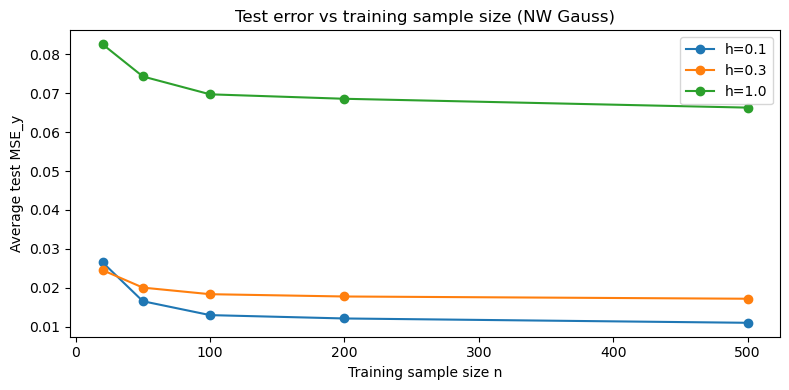

In [13]:
n_values   = [20, 50, 100, 200, 500]
h_values_t = [0.1, 0.3, 1.0]  # three bandwidth choices
n_repeats  = 10

# fixed large test set
X_test_large, y_test_large = generate_data(n=500, seed=0)

results = {h: [] for h in h_values_t}  # h -> list of avg MSE per n

for n in n_values:
    mse_per_h = {h: [] for h in h_values_t}
    for rep in range(n_repeats):
        X_tr, y_tr = generate_data(n, seed=rep*100)
        for h in h_values_t:
            y_pred = nw_predict(gaussian_kernel, X_tr, y_tr, h, X_test_large)
            mse = np.nanmean((y_pred - y_test_large)**2)
            mse_per_h[h].append(mse)
    for h in h_values_t:
        results[h].append(np.mean(mse_per_h[h]))

plt.figure(figsize=(8, 4))
for h in h_values_t:
    plt.plot(n_values, results[h], marker='o', label=f'h={h}')
plt.xlabel('Training sample size n')
plt.ylabel('Average test MSE_y')
plt.title('Test error vs training sample size (NW Gauss)')
plt.legend()
plt.tight_layout()
plt.show()

**Observations:**

- Increasing $n$ helps for all $h$, but more so for small $h$ — larger samples fill the neighbourhood.
- **Why $h$ should decrease with $n$:** as data gets denser, we can afford a smaller neighbourhood and still average over many points — this reduces bias without increasing variance too much.
- **$h$ too large:** bias dominates even with many data — the estimate is too smooth regardless of $n$.
- **$h$ decreasing too fast:** the neighbourhood empties quickly — high variance, NaN predictions.

## Task 8: Local vs global — how a new observation affects the fitted curve

**Nadaraya-Watson** is **highly local**: a new observation only affects predictions at nearby $x$ values (within a few $h$). Points far away receive essentially zero weight from the Gaussian kernel.

**Smoothing splines** are **more global**: the spline minimises a penalised loss over the whole domain, so adding a point can shift the curve even at distant locations (though the effect decays). The spline must stay globally smooth.

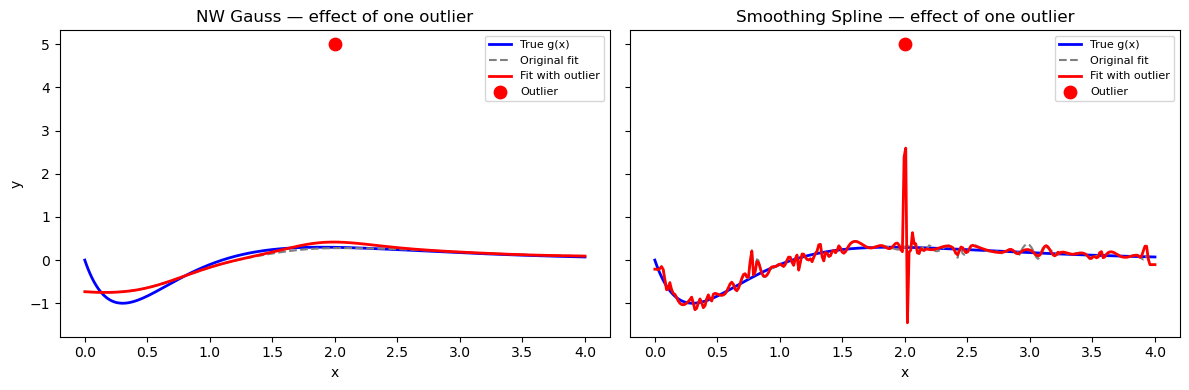

In [14]:
# Demonstrate locality: add a single outlier point
x_outlier = 2.0
y_outlier  = 5.0   # far from g(2) ≈ 0

X_aug = np.append(X_train, x_outlier)
y_aug = np.append(y_train, y_outlier)
idx_aug = np.argsort(X_aug)

y_nw_aug = nw_predict(gaussian_kernel, X_aug, y_aug, h_best, x_grid)
sp_aug   = UnivariateSpline(X_aug[idx_aug], y_aug[idx_aug], s=s_best, ext='const')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (y_orig, y_new, title) in zip(axes, [
    (y_nw_gauss, y_nw_aug, 'NW Gauss — effect of one outlier'),
    (sp_best(x_grid), sp_aug(x_grid), 'Smoothing Spline — effect of one outlier')
]):
    ax.plot(x_grid, g(x_grid), 'b-', lw=2, label='True g(x)')
    ax.plot(x_grid, y_orig, 'gray', lw=1.5, linestyle='--', label='Original fit')
    ax.plot(x_grid, y_new,  'red',  lw=2,   label='Fit with outlier')
    ax.scatter([x_outlier], [y_outlier], color='red', s=80, zorder=5, label='Outlier')
    ax.set_title(title); ax.set_xlabel('x'); ax.legend(fontsize=8)
axes[0].set_ylabel('y')
plt.tight_layout()
plt.show()

## Task 9: Smoothing parameter as a model selection problem

Compare training vs test error across parameter values to illustrate why we need proper model selection.

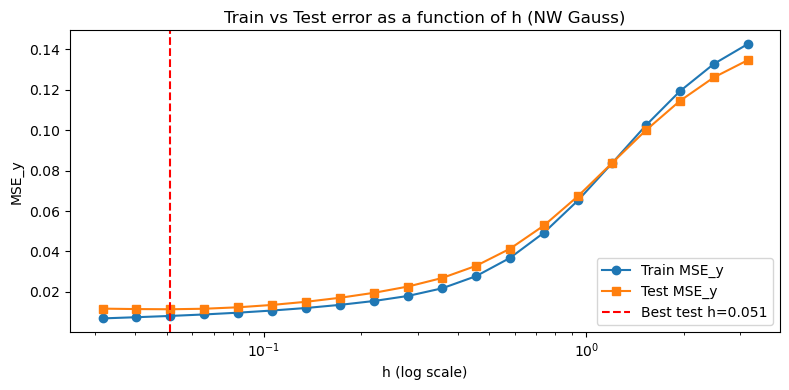

Best h by test error: 0.0513


In [15]:
h_grid = np.logspace(-1.5, 0.5, 20)  # from ~0.03 to ~3

train_errors, test_errors = [], []

for h in h_grid:
    y_tr_pred  = nw_predict(gaussian_kernel, X_train, y_train, h, X_train)
    y_te_pred  = nw_predict(gaussian_kernel, X_train, y_train, h, X_test)
    train_errors.append(np.nanmean((y_tr_pred - y_train)**2))
    test_errors.append( np.nanmean((y_te_pred  - y_test )**2))

best_h = h_grid[np.argmin(test_errors)]

plt.figure(figsize=(8, 4))
plt.plot(h_grid, train_errors, 'o-', label='Train MSE_y')
plt.plot(h_grid, test_errors,  's-', label='Test MSE_y')
plt.axvline(best_h, color='red', linestyle='--', label=f'Best test h={best_h:.3f}')
plt.xscale('log')
plt.xlabel('h (log scale)'); plt.ylabel('MSE_y')
plt.title('Train vs Test error as a function of h (NW Gauss)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best h by test error: {best_h:.4f}")

**Why smoothing parameter selection is a model selection problem:**

- **Training error** decreases monotonically as $h \to 0$ (overfit) — useless for selection.
- **Test error** has a U-shape: too small $h$ → high variance; too large $h$ → high bias.
- We cannot use training error to pick $h$ — it always favours the most complex model.
- In practice we don't have a separate test set, so we use **cross-validation** (e.g. leave-one-out or k-fold) to estimate test error from training data.
- Using the test set for selection would cause **data leakage** — the test set must remain unseen until final evaluation.